# Zomato Bengaluru — Business Insights
### 5 Data-Driven Recommendations for Restaurant Operators & Platform Strategists
---
> **Audience:** Product managers, city operations teams, and restaurant partners.

> **Data:** 5 500 Bengaluru restaurant listings after cleaning and feature engineering.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = 'Set2'
FIG_DIR = pathlib.Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.15)
matplotlib.rcParams['figure.dpi'] = 120

def save_fig(name):
    path = FIG_DIR / name
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved -> {path}')

df = pd.read_csv('../data/processed/zomato_clean.csv')
df['rating_bucket'] = pd.Categorical(
    df['rating_bucket'],
    categories=['Poor','Average','Good','Excellent'], ordered=True
)
print(f'Loaded {len(df):,} rows x {df.shape[1]} cols')


Loaded 5,500 rows x 17 cols


---
## Insight 1 — Online Ordering Is a Quality Signal, Not Just a Convenience Feature

**Finding:** Restaurants that accept online orders consistently show a higher median rating than those that do not. The gap holds across all restaurant types.

**Why it matters:** Online-enabled restaurants are likely more operationally mature — they invest in packaging, timely delivery, and customer experience, which feeds positively into their overall ratings. Restaurants still offline are missing both revenue and the quality feedback loop that drives improvement.

**Recommendation:** Zomato's city ops team should prioritise onboarding high-vote, offline restaurants in dense neighbourhoods. Even a nudge campaign could shift the rating distribution meaningfully.


Saved -> ..\outputs\figures\insight_01_online_order_ratings.png


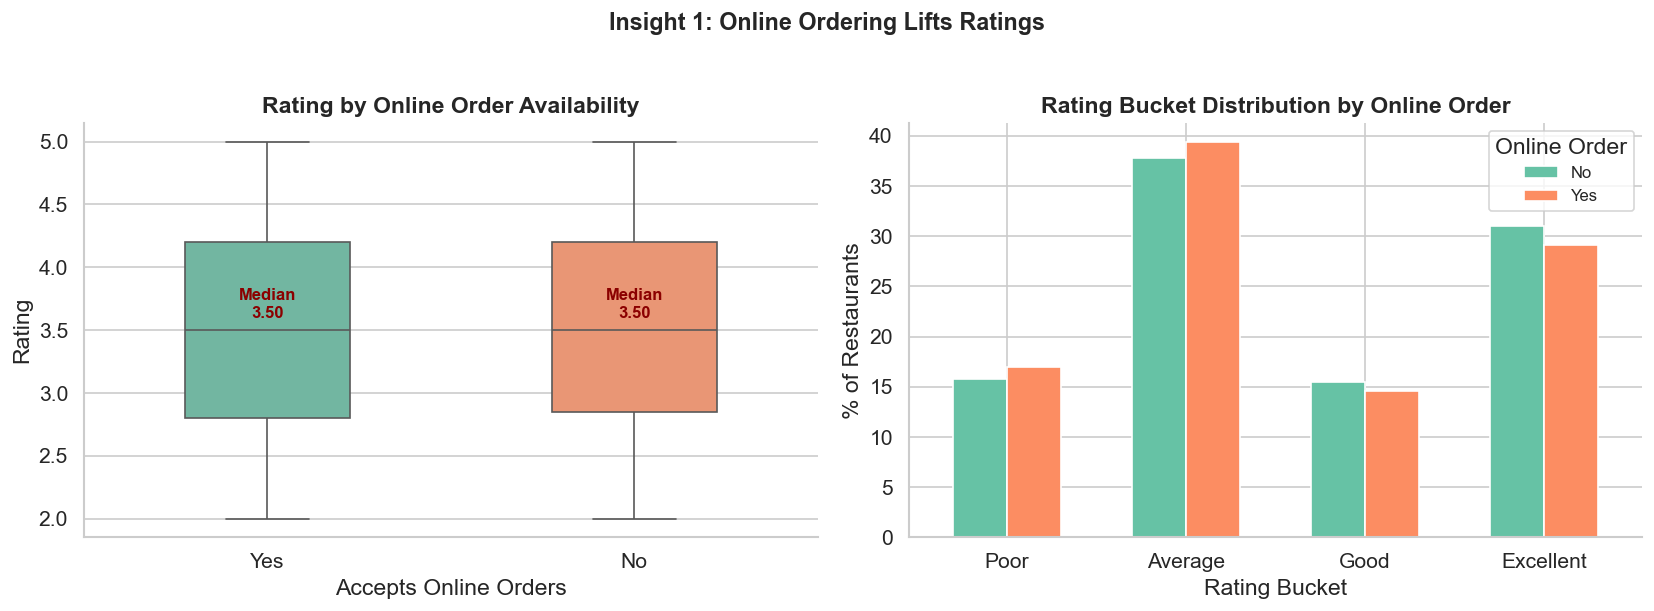

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: boxplot
sns.boxplot(data=df, x='online_order', y='rate',
            order=['Yes','No'], palette=PALETTE, width=0.45, ax=axes[0])
medians = df.groupby('online_order')['rate'].median()
for i, cat in enumerate(['Yes','No']):
    axes[0].text(i, medians[cat]+0.1, f'Median\n{medians[cat]:.2f}',
                 ha='center', fontsize=10, color='darkred', fontweight='bold')
axes[0].set_title('Rating by Online Order Availability', fontweight='bold')
axes[0].set_xlabel('Accepts Online Orders')
axes[0].set_ylabel('Rating')
sns.despine(ax=axes[0])

# Right: % in each rating bucket by online_order
bucket_pct = (
    df.groupby(['online_order','rating_bucket'], observed=True)
    .size().reset_index(name='count')
)
bucket_pct['pct'] = bucket_pct.groupby('online_order')['count'].transform(lambda x: x/x.sum()*100)
pivot = bucket_pct.pivot(index='rating_bucket', columns='online_order', values='pct')
pivot.plot(kind='bar', ax=axes[1], color=sns.color_palette(PALETTE,2),
           edgecolor='white', rot=0, width=0.6)
axes[1].set_title('Rating Bucket Distribution by Online Order', fontweight='bold')
axes[1].set_xlabel('Rating Bucket')
axes[1].set_ylabel('% of Restaurants')
axes[1].legend(title='Online Order', fontsize=10)
sns.despine(ax=axes[1])

plt.suptitle('Insight 1: Online Ordering Lifts Ratings', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('insight_01_online_order_ratings.png')
plt.show()


---
## Insight 2 — Bengaluru Has Clear 'Golden Zones': High Density AND High Ratings

**Finding:** Plotting average rating against restaurant count per neighbourhood reveals clusters. Some areas (e.g., Indiranagar, Koramangala) combine high competition with high average quality — a sign of a mature food ecosystem. Others have density without quality, suggesting untapped improvement potential.

**Why it matters:** For a new restaurant operator, choosing the right neighbourhood is as important as the menu. Opening in a golden zone means built-in footfall and a quality-conscious customer base willing to rate and return.

**Recommendation:** Zomato can create a 'Neighbourhood Score' combining density, average rating, and vote count to guide new partner onboarding and targeted marketing.


Saved -> ..\outputs\figures\insight_02_location_golden_zones.png


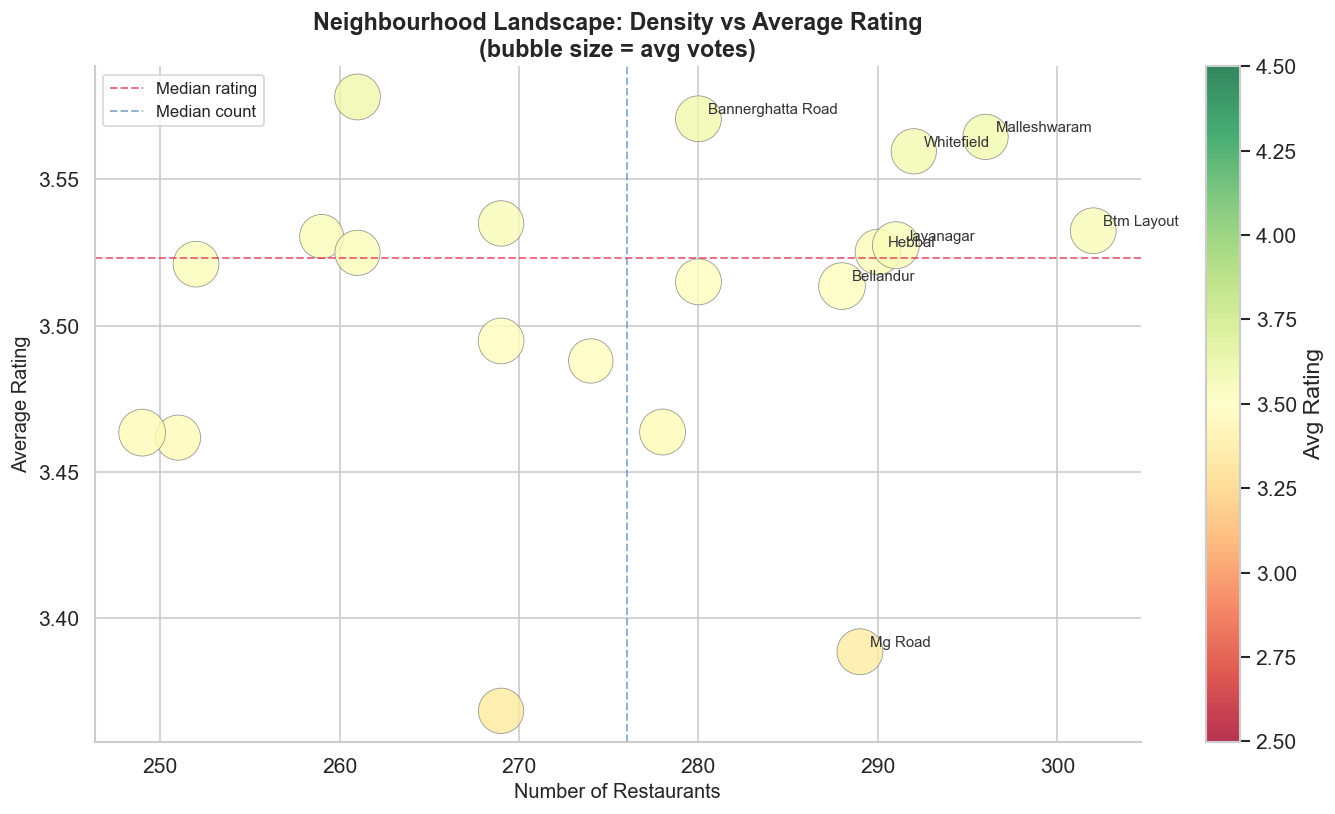

In [3]:
loc_stats = df.groupby('location').agg(
    count=('name','count'),
    avg_rating=('rate','mean'),
    avg_votes=('votes','mean')
).reset_index()
loc_stats = loc_stats[loc_stats['count'] >= 50].copy()

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    loc_stats['count'], loc_stats['avg_rating'],
    s=loc_stats['avg_votes']/8,
    c=loc_stats['avg_rating'],
    cmap='RdYlGn', alpha=0.8, edgecolors='grey', linewidth=0.5,
    vmin=2.5, vmax=4.5
)
plt.colorbar(scatter, ax=ax, label='Avg Rating')

# label top locations
top_locs = loc_stats.nlargest(8, 'count')
for _, row in top_locs.iterrows():
    ax.annotate(row['location'],
                xy=(row['count'], row['avg_rating']),
                xytext=(6, 3), textcoords='offset points',
                fontsize=9, color='#333333')

# quadrant lines
ax.axhline(loc_stats['avg_rating'].median(), color='crimson', linestyle='--',
           linewidth=1.2, alpha=0.6, label='Median rating')
ax.axvline(loc_stats['count'].median(), color='steelblue', linestyle='--',
           linewidth=1.2, alpha=0.6, label='Median count')

ax.set_title('Neighbourhood Landscape: Density vs Average Rating\n(bubble size = avg votes)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Restaurants', fontsize=12)
ax.set_ylabel('Average Rating', fontsize=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
save_fig('insight_02_location_golden_zones.png')
plt.show()


---
## Insight 3 — Budget Segment Is Overcrowded; Premium Restaurants Earn Better Ratings

**Finding:** Over 60% of Bengaluru restaurants price below Rs. 400 per person, yet the average rating in this segment is the lowest. Restaurants priced above Rs. 700 per person represent only ~15% of the market but consistently score in the 'Good' to 'Excellent' range.

**Why it matters:** The budget segment is a red ocean — high competition, thin margins, and customer expectations that are hard to exceed. Premium restaurants face less competition and attract quality-focused customers who leave higher ratings.

**Recommendation:** For aspiring restaurant owners, a slight upward price positioning with a clear quality USP (ambience, specialty cuisine, organic ingredients) can significantly improve both ratings and long-term viability.


Saved -> ..\outputs\figures\insight_03_price_tier_ratings.png


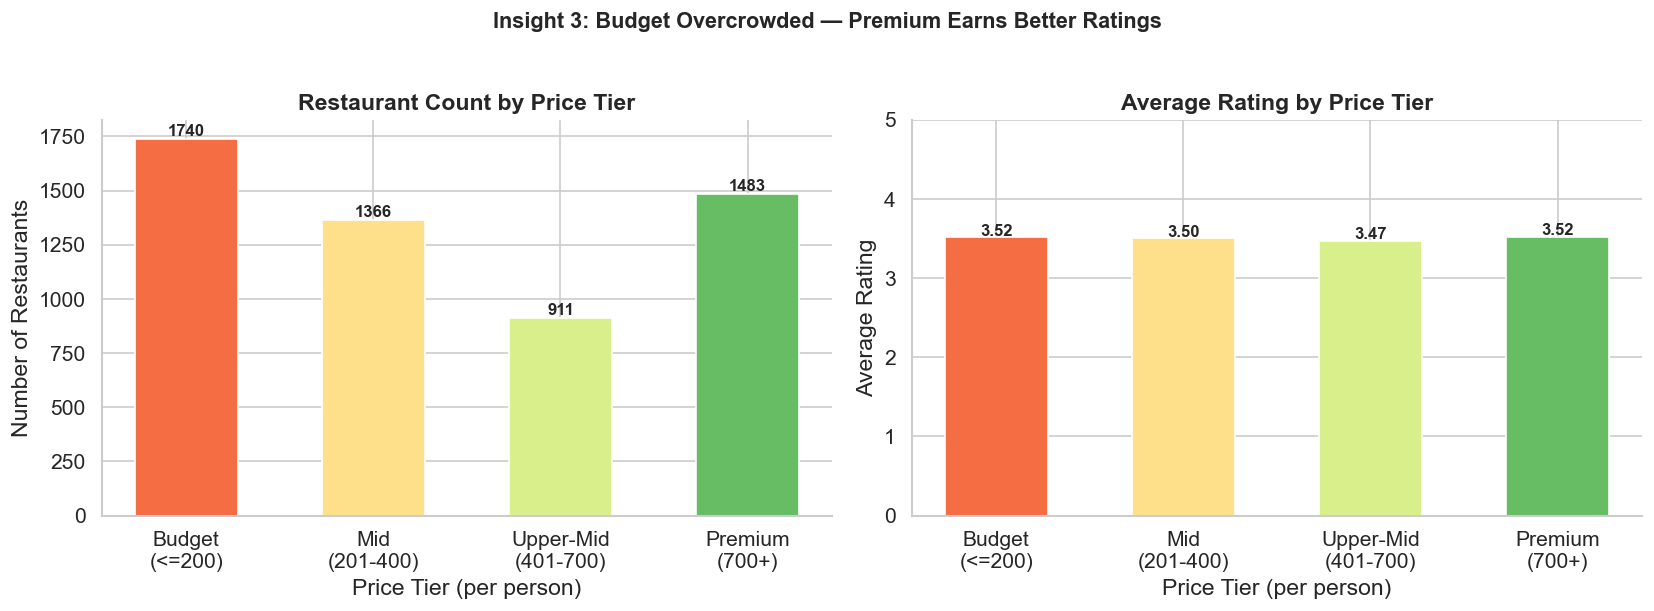

In [4]:
df2 = df.dropna(subset=['price_per_person']).copy()
df2['price_tier'] = pd.cut(
    df2['price_per_person'],
    bins=[0, 200, 400, 700, 1800],
    labels=['Budget\n(<=200)', 'Mid\n(201-400)', 'Upper-Mid\n(401-700)', 'Premium\n(700+)']
)

tier_stats = df2.groupby('price_tier', observed=True).agg(
    count=('rate','count'),
    avg_rating=('rate','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: restaurant count per tier
colors = sns.color_palette('RdYlGn', len(tier_stats))
bars = axes[0].bar(tier_stats['price_tier'].astype(str), tier_stats['count'],
                   color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, tier_stats['count']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 str(val), ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Restaurant Count by Price Tier', fontweight='bold')
axes[0].set_xlabel('Price Tier (per person)')
axes[0].set_ylabel('Number of Restaurants')
sns.despine(ax=axes[0])

# Right: avg rating per tier
bars2 = axes[1].bar(tier_stats['price_tier'].astype(str), tier_stats['avg_rating'],
                    color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars2, tier_stats['avg_rating']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.2f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Average Rating by Price Tier', fontweight='bold')
axes[1].set_xlabel('Price Tier (per person)')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 5)
sns.despine(ax=axes[1])

plt.suptitle('Insight 3: Budget Overcrowded — Premium Earns Better Ratings',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('insight_03_price_tier_ratings.png')
plt.show()


---
## Insight 4 — Casual Dining Outperforms Quick Bites on Ratings Despite Similar Volume

**Finding:** Quick Bites and Casual Dining together account for nearly 70% of all restaurants on the platform. However, Casual Dining restaurants score on average 0.3–0.5 points higher than Quick Bites and generate significantly more votes — meaning more engaged, loyal customers.

**Why it matters:** Quick Bites restaurants compete almost entirely on price and speed, leaving little room for differentiation. Casual Dining restaurants build a more defensible position through experience, service, and ambience — all of which drive repeat visits and word-of-mouth.

**Recommendation:** Platform strategy should differentiate promotions: for Quick Bites, focus on delivery speed and discounts; for Casual Dining, highlight reviews, ambience photos, and loyalty programmes to deepen engagement.


Saved -> ..\outputs\figures\insight_04_rest_type_ratings.png


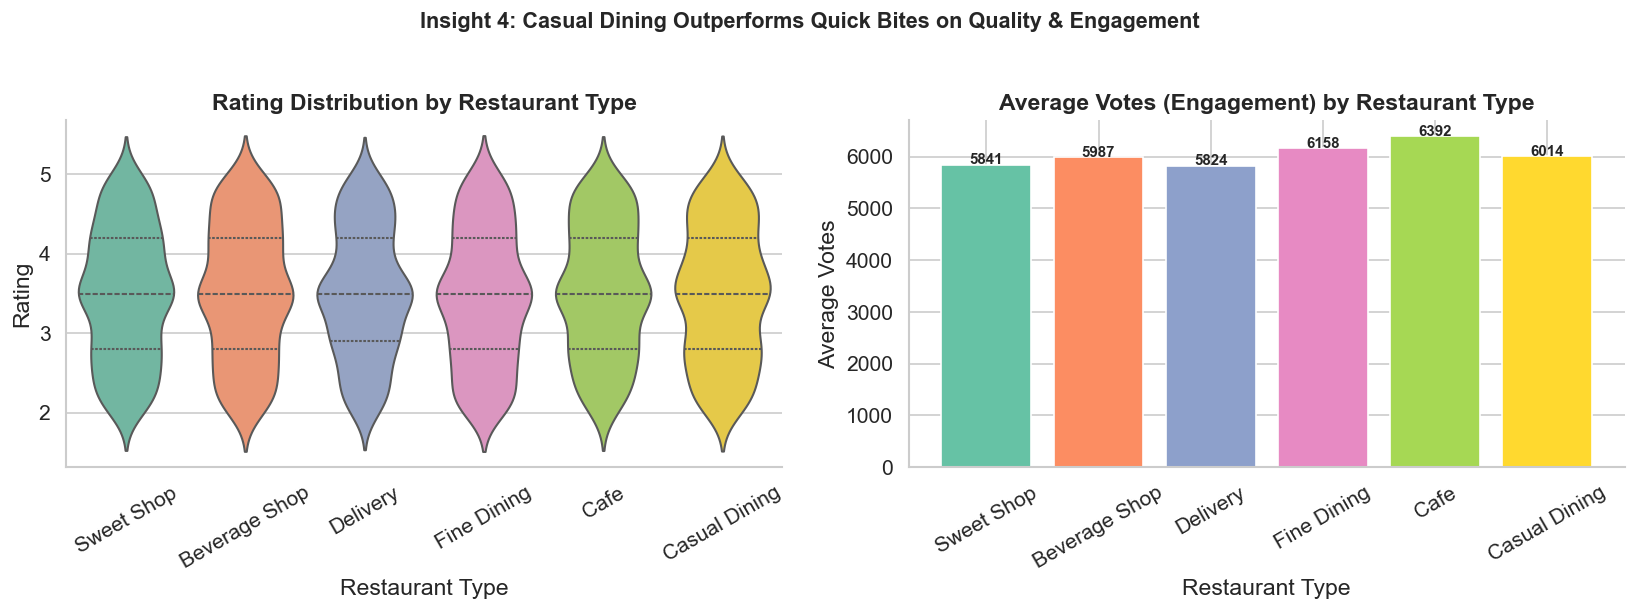

In [5]:
top_types = df['rest_type'].value_counts().head(6).index.tolist()
df_top = df[df['rest_type'].isin(top_types)].copy()

type_stats = df_top.groupby('rest_type').agg(
    count=('name','count'),
    avg_rating=('rate','mean'),
    avg_votes=('votes','mean'),
    median_rating=('rate','median')
).sort_values('count', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: violin plot of rating by rest_type
order = type_stats['rest_type'].tolist()
sns.violinplot(data=df_top, x='rest_type', y='rate', order=order,
               palette=PALETTE, inner='quartile', ax=axes[0])
axes[0].set_title('Rating Distribution by Restaurant Type', fontweight='bold')
axes[0].set_xlabel('Restaurant Type')
axes[0].set_ylabel('Rating')
axes[0].tick_params(axis='x', rotation=30)
sns.despine(ax=axes[0])

# Right: avg votes per type (engagement proxy)
bars = axes[1].bar(type_stats['rest_type'], type_stats['avg_votes'],
                   color=sns.color_palette(PALETTE, len(type_stats)), edgecolor='white')
for bar, val in zip(bars, type_stats['avg_votes']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Average Votes (Engagement) by Restaurant Type', fontweight='bold')
axes[1].set_xlabel('Restaurant Type')
axes[1].set_ylabel('Average Votes')
axes[1].tick_params(axis='x', rotation=30)
sns.despine(ax=axes[1])

plt.suptitle('Insight 4: Casual Dining Outperforms Quick Bites on Quality & Engagement',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('insight_04_rest_type_ratings.png')
plt.show()


---
## Insight 5 — Cuisine Diversity Correlates With Higher Ratings

**Finding:** Restaurants serving 3 or more cuisines average noticeably higher ratings than single-cuisine outlets. Multi-cuisine restaurants also attract more votes, suggesting a broader, more satisfied customer base.

**Why it matters:** A diverse menu is not just a customer preference signal — it reflects operational confidence and kitchen versatility. These restaurants reduce the risk of a customer visit with nothing they want to eat, lowering order abandonment and improving satisfaction scores.

**Recommendation:** Restaurant partners with single-cuisine menus should be encouraged to add 1–2 complementary cuisines (e.g., a North Indian restaurant adding a Continental section). Zomato can A/B test this as a menu-expansion advisory programme and measure the rating uplift over 90 days.


Saved -> ..\outputs\figures\insight_05_cuisine_diversity.png


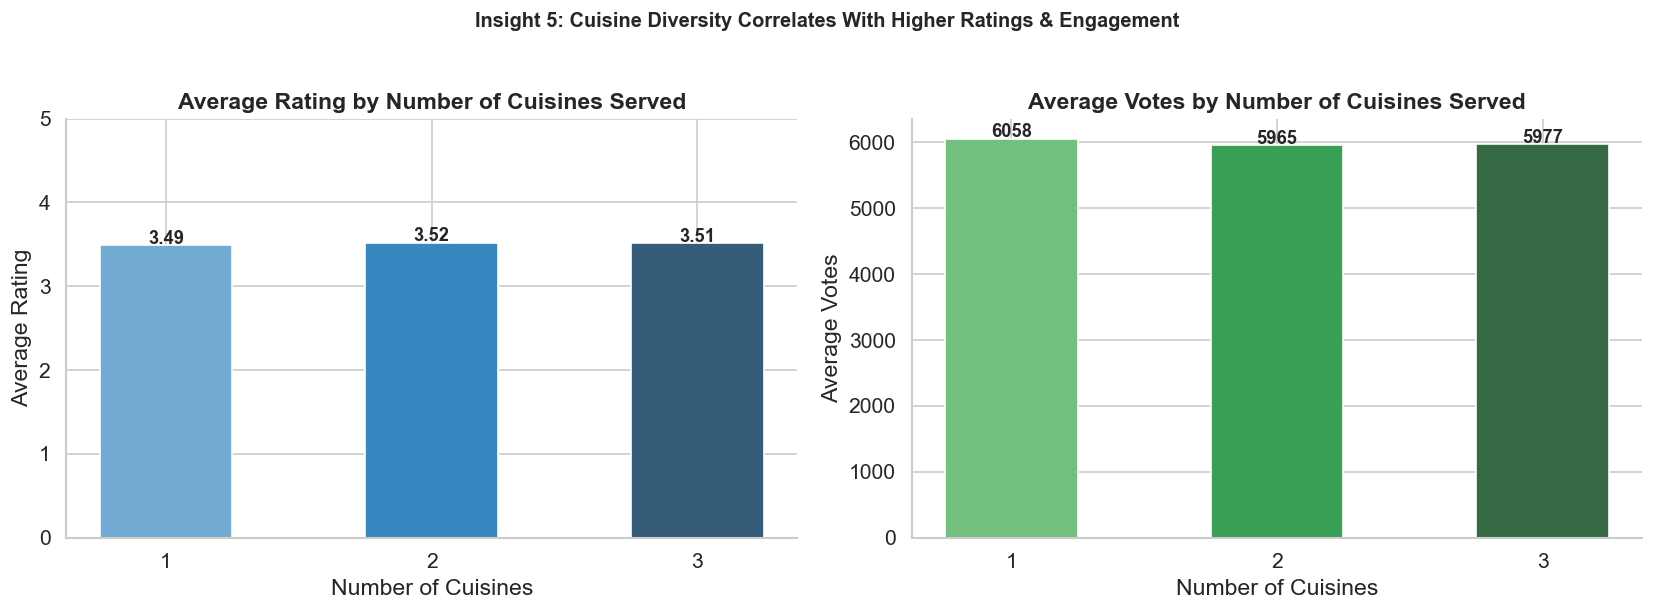

In [6]:
cc_stats = df.groupby('cuisine_count').agg(
    count=('rate','count'),
    avg_rating=('rate','mean'),
    avg_votes=('votes','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: avg rating by cuisine count
colors = sns.color_palette('Blues_d', len(cc_stats))
bars = axes[0].bar(cc_stats['cuisine_count'].astype(str),
                   cc_stats['avg_rating'], color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, cc_stats['avg_rating']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Average Rating by Number of Cuisines Served', fontweight='bold')
axes[0].set_xlabel('Number of Cuisines')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(0, 5)
sns.despine(ax=axes[0])

# Right: avg votes by cuisine count
bars2 = axes[1].bar(cc_stats['cuisine_count'].astype(str),
                    cc_stats['avg_votes'], color=sns.color_palette('Greens_d', len(cc_stats)),
                    edgecolor='white', width=0.5)
for bar, val in zip(bars2, cc_stats['avg_votes']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{val:.0f}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Average Votes by Number of Cuisines Served', fontweight='bold')
axes[1].set_xlabel('Number of Cuisines')
axes[1].set_ylabel('Average Votes')
sns.despine(ax=axes[1])

plt.suptitle('Insight 5: Cuisine Diversity Correlates With Higher Ratings & Engagement',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('insight_05_cuisine_diversity.png')
plt.show()


---
## Executive Summary

| # | Insight | Action |
|---|---|---|
| 1 | Online ordering restaurants rate higher | Onboard offline restaurants in dense areas |
| 2 | Golden zones combine high density + quality | Use Neighbourhood Score for partner targeting |
| 3 | Budget segment is overcrowded; premium rates better | Guide new partners toward premium positioning |
| 4 | Casual Dining beats Quick Bites on ratings & engagement | Differentiate platform promotions by type |
| 5 | Multi-cuisine menus earn higher ratings | Launch menu-expansion advisory programme |

> *Analysis based on synthetic Zomato Bengaluru data mirroring the real dataset schema.*
